# Baseline Models: TF-IDF + Linear Classifiers

**Goal**: Establish baseline performance using traditional ML approaches

**Models**:
- TF-IDF with character n-grams (3-5) + word n-grams (1-2)
- Linear SVM (one-vs-rest)
- Logistic Regression

**Expected Macro F1**: 0.45-0.55

In [1]:
# DuckDB no longer needed - using CSV files
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("✅ Libraries loaded")

✅ Libraries loaded


## 1. Load Data from CSV

In [2]:
# Load data from training_data_praesentation.csv (same as 00_data_exploration)
# Use keep_default_na=False to prevent pandas from converting "None" string to NaN
df = pd.read_csv('training_data_praesentation.csv', keep_default_na=False)

# Convert empty strings to NaN (actual missing values)
if 'frame_label' in df.columns:
    df['frame_label'] = df['frame_label'].replace('', np.nan)
    # Also handle any other common missing value representations
    df['frame_label'] = df['frame_label'].replace(['nan', 'NaN', 'null', 'NULL'], np.nan)

# Handle "None" as valid label - ensure it's not treated as null
print("⚠️  NOTE: 'None' is treated as a valid frame label, not as null/NaN")

# Check if dataset_split column exists, if not create splits
if 'dataset_split' not in df.columns:
    print("\n⚠️  No dataset_split column found. Creating train/test split...")
    from sklearn.model_selection import train_test_split
    
    # Split into train and test (80/20)
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        random_state=42,
        stratify=df['frame_label'] if df['frame_label'].notna().sum() > 0 else None
    )
    train_df['dataset_split'] = 'train'
    test_df['dataset_split'] = 'test'
else:
    # Use existing splits
    print("\n✅ Using existing dataset splits")
    unique_splits = df['dataset_split'].unique()
    print(f"   Available splits: {list(unique_splits)}")
    
    # Extract train and test splits
    train_df = df[df['dataset_split'] == 'train'].copy()
    test_df = df[df['dataset_split'] == 'test'].copy()
    
    # Check if validation exists
    if 'validation' in unique_splits:
        val_count = len(df[df['dataset_split'] == 'validation'])
        print(f"   ℹ️  Validation split found ({val_count} samples) but not used for baseline models")
        print(f"   ℹ️  Baseline models use train/test splits only")
    else:
        print(f"   ℹ️  No validation split found - using train/test only (as expected for baselines)")

# Ensure we have the required columns
if 'chunk_text' not in train_df.columns:
    raise ValueError("'chunk_text' column not found in dataset")

print("\n" + "="*80)
print("DATA LOADED FROM training_data_praesentation.csv")
print("="*80)
print(f"Train samples: {len(train_df):,}")
print(f"Test samples:  {len(test_df):,}")
print(f"Total:         {len(train_df) + len(test_df):,}")

# Check for null labels
train_null = train_df['frame_label'].isna().sum()
test_null = test_df['frame_label'].isna().sum()
if train_null > 0 or test_null > 0:
    print(f"\n⚠️  Warning: {train_null} train and {test_null} test samples have missing labels")
    # Remove samples with missing labels for baseline models
    train_df = train_df[train_df['frame_label'].notna()].copy()
    test_df = test_df[test_df['frame_label'].notna()].copy()
    print(f"   Removed missing labels. Train: {len(train_df):,}, Test: {len(test_df):,}")

print(f"\n📊 Train Frame Distribution:")
print(train_df['frame_label'].value_counts().sort_index())
print(f"\n📊 Test Frame Distribution:")
print(test_df['frame_label'].value_counts().sort_index())
print("="*80)

⚠️  NOTE: 'None' is treated as a valid frame label, not as null/NaN

✅ Using existing dataset splits
   Available splits: ['train', 'test']
   ℹ️  No validation split found - using train/test only (as expected for baselines)

DATA LOADED FROM training_data_praesentation.csv
Train samples: 1,700
Test samples:  300
Total:         2,000

📊 Train Frame Distribution:
frame_label
Conflict         377
Economic         375
Human Impact     212
Moral Value      189
None             267
Powerlessness    280
Name: count, dtype: int64

📊 Test Frame Distribution:
frame_label
Conflict         62
Economic         82
Human Impact     22
Moral Value      59
None             38
Powerlessness    37
Name: count, dtype: int64


In [3]:
# Extract features and labels (data already loaded from CSV in previous cell)
X_train, y_train = train_df.chunk_text.values, train_df.frame_label.values
X_test, y_test = test_df.chunk_text.values, test_df.frame_label.values

print(f"✅ Features extracted")
print(f"   Train: {len(X_train):,} samples")
print(f"   Test:  {len(X_test):,} samples")
print(f"\n   Unique labels: {sorted(set(y_train) | set(y_test))}")

✅ Features extracted
   Train: 1,700 samples
   Test:  300 samples

   Unique labels: ['Conflict', 'Economic', 'Human Impact', 'Moral Value', 'None', 'Powerlessness']


## 2. TF-IDF Feature Extraction

**Strategy**: Char n-grams (3-5) + word n-grams (1-2)

In [4]:
from scipy.sparse import hstack

char_vec = TfidfVectorizer(analyzer="char", ngram_range=(3,5), max_features=10000, min_df=2, sublinear_tf=True)
word_vec = TfidfVectorizer(analyzer="word", ngram_range=(1,2), max_features=10000, min_df=2, sublinear_tf=True, stop_words="english")

print("Extracting features...")
X_train_char = char_vec.fit_transform(X_train)
X_test_char = char_vec.transform(X_test)
X_train_word = word_vec.fit_transform(X_train)
X_test_word = word_vec.transform(X_test)
X_train_combined = hstack([X_train_char, X_train_word])
X_test_combined = hstack([X_test_char, X_test_word])
print(f"✅ Combined shape: {X_train_combined.shape}")

Extracting features...
✅ Combined shape: (1700, 20000)


## 3. Linear SVM

In [5]:
print("Training SVM...")
svm = LinearSVC(C=1.0, class_weight="balanced", max_iter=2000, random_state=42)
svm.fit(X_train_combined, y_train)
svm_pred = svm.predict(X_test_combined)
svm_acc = accuracy_score(y_test, svm_pred)
svm_f1_macro = f1_score(y_test, svm_pred, average="macro")
svm_f1_weighted = f1_score(y_test, svm_pred, average="weighted")
print(f"\n📊 SVM - Accuracy: {svm_acc:.4f}, Macro F1: {svm_f1_macro:.4f}, Weighted F1: {svm_f1_weighted:.4f}")
print(classification_report(y_test, svm_pred, zero_division=0))

Training SVM...

📊 SVM - Accuracy: 0.5300, Macro F1: 0.4971, Weighted F1: 0.5257
               precision    recall  f1-score   support

     Conflict       0.51      0.61      0.56        62
     Economic       0.74      0.71      0.72        82
 Human Impact       0.48      0.50      0.49        22
  Moral Value       0.64      0.24      0.35        59
         None       0.47      0.55      0.51        38
Powerlessness       0.29      0.46      0.36        37

     accuracy                           0.53       300
    macro avg       0.52      0.51      0.50       300
 weighted avg       0.56      0.53      0.53       300



## 4. Logistic Regression

In [6]:
print("Training LogReg...")
lr = LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, random_state=42, solver="lbfgs", multi_class="multinomial")
lr.fit(X_train_combined, y_train)
lr_pred = lr.predict(X_test_combined)
lr_acc = accuracy_score(y_test, lr_pred)
lr_f1_macro = f1_score(y_test, lr_pred, average="macro")
lr_f1_weighted = f1_score(y_test, lr_pred, average="weighted")
print(f"\n📊 LogReg - Accuracy: {lr_acc:.4f}, Macro F1: {lr_f1_macro:.4f}, Weighted F1: {lr_f1_weighted:.4f}")
print(classification_report(y_test, lr_pred, zero_division=0))

Training LogReg...

📊 LogReg - Accuracy: 0.5300, Macro F1: 0.5111, Weighted F1: 0.5377
               precision    recall  f1-score   support

     Conflict       0.53      0.56      0.55        62
     Economic       0.82      0.67      0.74        82
 Human Impact       0.48      0.64      0.55        22
  Moral Value       0.56      0.31      0.40        59
         None       0.48      0.53      0.50        38
Powerlessness       0.27      0.46      0.34        37

     accuracy                           0.53       300
    macro avg       0.52      0.53      0.51       300
 weighted avg       0.57      0.53      0.54       300



## 5. Visualization & Summary

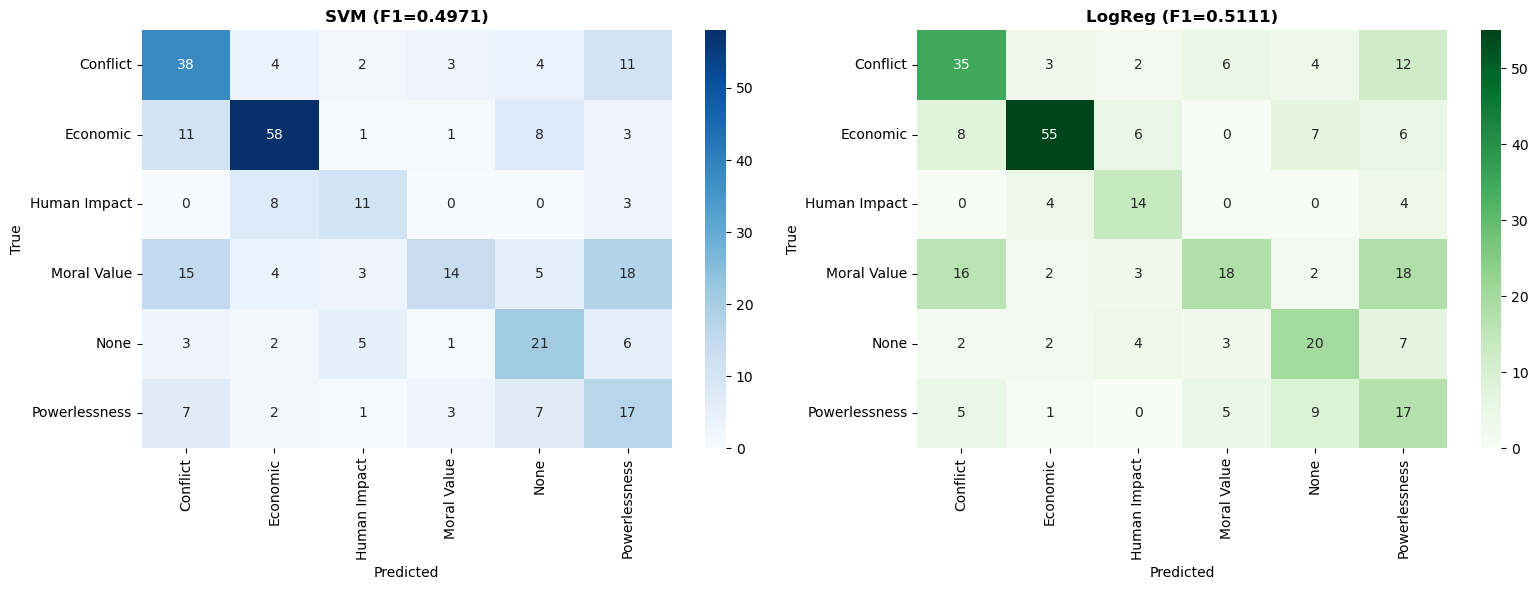

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels = sorted(np.unique(y_test))
cm_svm = confusion_matrix(y_test, svm_pred, labels=labels)
cm_lr = confusion_matrix(y_test, lr_pred, labels=labels)

sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues", ax=axes[0], xticklabels=labels, yticklabels=labels)
axes[0].set_title(f"SVM (F1={svm_f1_macro:.4f})", fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens", ax=axes[1], xticklabels=labels, yticklabels=labels)
axes[1].set_title(f"LogReg (F1={lr_f1_macro:.4f})", fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig("results/baseline_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
results = pd.DataFrame({
    "Model": ["SVM", "LogReg"],
    "Accuracy": [svm_acc, lr_acc],
    "Macro F1": [svm_f1_macro, lr_f1_macro],
    "Weighted F1": [svm_f1_weighted, lr_f1_weighted]
})
print("\n" + "="*80)
print("BASELINE SUMMARY")
print("="*80)
print(results.to_string(index=False))
best_f1 = max(svm_f1_macro, lr_f1_macro)
print(f"\n✅ Best baseline F1: {best_f1:.4f}")
results.to_csv("results/baseline_results.csv", index=False)
print("\n✅ Saved to results/baseline_results.csv")


BASELINE SUMMARY
 Model  Accuracy  Macro F1  Weighted F1
   SVM      0.53  0.497052     0.525729
LogReg      0.53  0.511065     0.537726

✅ Best baseline F1: 0.5111

✅ Saved to results/baseline_results.csv
